In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
#DataSet Loading

data=pd.read_csv("housing.csv")
df=pd.DataFrame(data)
print("Dataset Loaded Succesfully:")
df.head()

Dataset Loaded Succesfully:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print("Missing Values in dataset:")
df.isnull().sum()

Missing Values in dataset:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [4]:
#Handle missing values
df["total_bedrooms"]=df["total_bedrooms"].fillna(df["total_bedrooms"].mean())
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [5]:
#Description of dataset
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


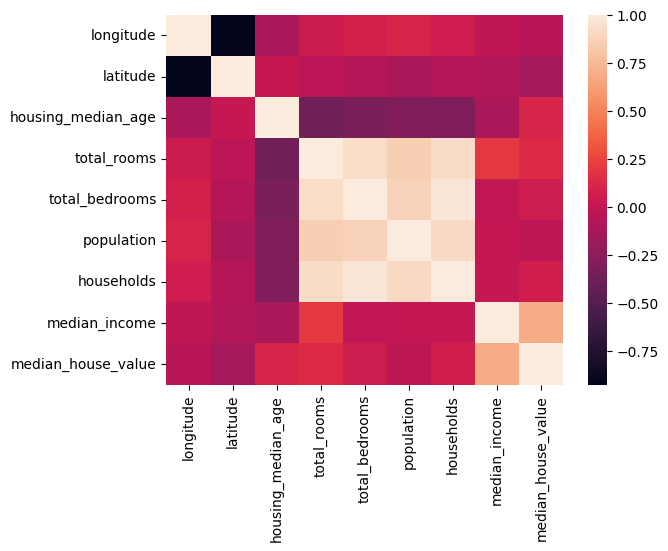

In [6]:
#Corr Heatmap
Corr=df.corr(numeric_only=True)
sns.heatmap(Corr)
plt.show()

In [7]:
e=LabelEncoder()
df["Location"]=e.fit_transform(df["ocean_proximity"])
print(df["Location"])


0        3
1        3
2        3
3        3
4        3
        ..
20635    1
20636    1
20637    1
20638    1
20639    1
Name: Location, Length: 20640, dtype: int64


In [8]:
#Feature Selection
X=df[["longitude","latitude","total_bedrooms","Location"]]
y=df["median_house_value"]




In [10]:
#Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
#Model Creation
def model(model,name):
    model.fit(X_train,y_train)
    price=model.predict(X_test)
    #RMSE
    rmse=np.sqrt(mean_squared_error(y_test,price))
    print(f"Root Mean Squared Error of {name} is:",rmse)
    #R2 Score
    r=r2_score(y_test,price)
    print(f"R2 Score of {name} is:",r)

In [13]:
#Linear Regression
model(LinearRegression(),"Linear Regression")

Root Mean Squared Error of Linear Regression is: 98766.0584972482
R2 Score of Linear Regression is: 0.2555961937793908


In [14]:
#Random Forest
model(RandomForestRegressor(),"Random Forest Regressor")

Root Mean Squared Error of Random Forest Regressor is: 52484.63873323558
R2 Score of Random Forest Regressor is: 0.7897879708779092


In [15]:
#predict on new data
new_data = {
    "longitude": [-122.25],
    "latitude": [37.85],
    "total_bedrooms": [400],
    "Location": 1,
    
}

# Convert to DataFrame
import pandas as pd
df = pd.DataFrame(new_data)
model=LinearRegression()
model.fit(X_train,y_train)
# Make prediction
predictedprice = model.predict(df)
print("Predicted house value:", predictedprice[0])


Predicted house value: 243565.42545744963
